# Exercise 10
**Cristina Correa - 1819211867**


Experiment with 3 different starting and ending points

Here I'll use the amount of miles we have to walk between cities

```
⭕-9.2-⭕       A — 9.2 — F
 | \    |        |\        |
 8 12.3 6.7      8 \       6.7
 |   \  |        |  12.3   |
⭕    `⭕       B      `— S
 |      |        |         |
 10.5   11.4     10.5      11.4
 |      |        |         |
⭕-11.3⭕       C —11.3 — D
```

In [26]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx


# Class representing a node in the graph
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name
        self.heuristic_cost = heuristic_cost
        self.adjacent = {}
        self.parent = None
        self.g_cost = float("inf")

    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

In [27]:
# A* search algorithm
def astar_search(start, goal):
    open_list = []
    closed_set = set()
    start.g_cost = 0
    heapq.heappush(open_list, start)

    while open_list:
        current_node = heapq.heappop(open_list)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]

        closed_set.add(current_node)

        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cost

            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost:
                continue

            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
    return None

In [28]:
# Creating nodes
A = Node("A", 3)
B = Node("B", 0)  # Washington
C = Node("C", 2)
D = Node("D", 1)
F = Node("F", 4)
S = Node("S", 2)  # Sunderland

# Adding neighbors and their costs
A.add_neighbor(F, 9.2)
A.add_neighbor(B, 8)
A.add_neighbor(S, 12.3)
B.add_neighbor(A, 8)
B.add_neighbor(C, 10.5)
C.add_neighbor(B, 10.5)
C.add_neighbor(D, 11.3)
D.add_neighbor(C, 11.3)
D.add_neighbor(S, 11.4)
S.add_neighbor(A, 12.3)
S.add_neighbor(F, 6.7)
S.add_neighbor(D, 11.4)
F.add_neighbor(A, 9.2)
F.add_neighbor(S, 6.7)

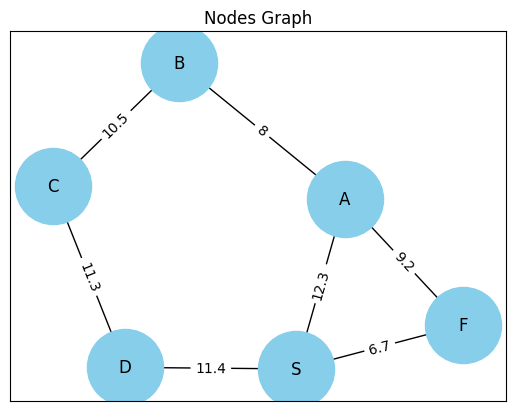

In [29]:
# Visualization without the solution
G = nx.Graph()
edges = [
    (A.name, F.name, {"weight": 9.2}),
    (A.name, B.name, {"weight": 8}),
    (A.name, S.name, {"weight": 12.3}),
    (B.name, C.name, {"weight": 10.5}),
    (C.name, D.name, {"weight": 11.3}),
    (D.name, S.name, {"weight": 11.4}),
    (F.name, S.name, {"weight": 6.7}),
]
G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Nodes Graph")
plt.show()

# First Experiment
**From A to D**

In [16]:
path1 = astar_search(A, D)
print("A* path1:", path1)

A* path1: ['A', 'S', 'D']


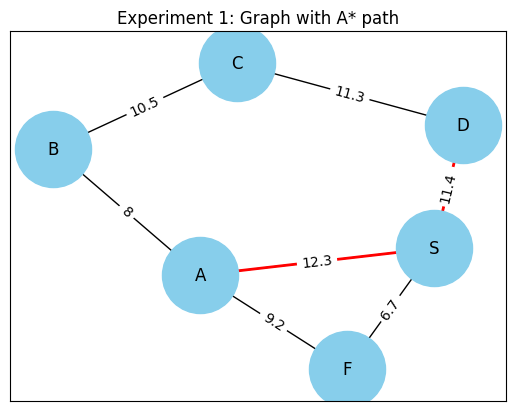

In [18]:
# Visualization with A* path
plt.title("Experiment 1: Graph with A* path")
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(path1[i], path1[i + 1]) for i in range(len(path1) - 1)],
    edge_color="r",
    width=2,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()

--------------------------------
# Second Experiment
*From F to C*

In [24]:
path2 = astar_search(F, C)
print("A* path2:", path2)

A* path2: ['F', 'A', 'B', 'C']


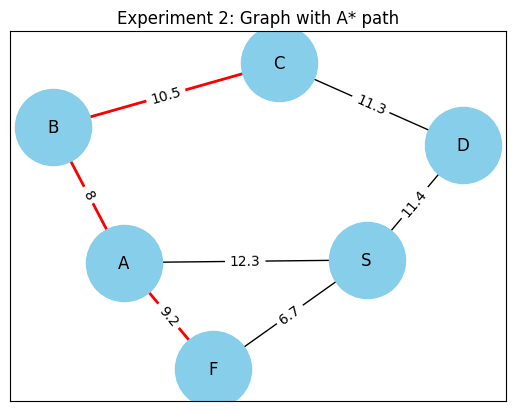

In [25]:
# Visualization with A* path
plt.title("Experiment 2: Graph with A* path")
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(path2[i], path2[i + 1]) for i in range(len(path2) - 1)],
    edge_color="r",
    width=2,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()

--------------------------------
# Third Experiment
*From C to S*

In [30]:
path3 = astar_search(C, S)
print("A* path3:", path3)

A* path3: ['C', 'D', 'S']


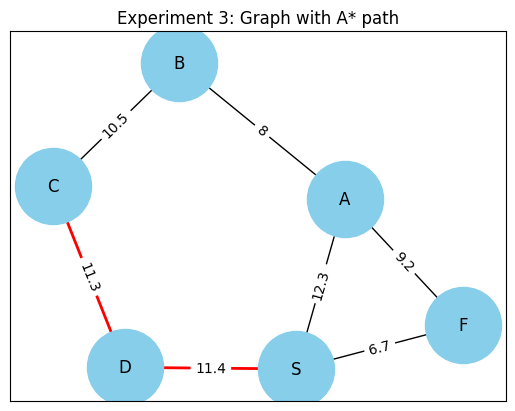

In [31]:
# Visualization with A* path
plt.title("Experiment 3: Graph with A* path")
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(path3[i], path3[i + 1]) for i in range(len(path3) - 1)],
    edge_color="r",
    width=2,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()